# **Automated Analysis Pipeline Notebook**
## Cervical Cancer Risk Factors: Predicting a Positive Biopsy

**Student Name:** Katerina Smith

---

**Dataset:** Cervical Cancer (Risk Factors), UCI Machine Learning Repository
<https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors>

**Description:** This dataset contains the history and screening results of 858 patients from Hospital Universitario de Caracas, Venezuela. The binary prediction task is to classify whether a patient's cervical biopsy is positive (Biopsy = 1) based on age, sexual and reproductive history, contraceptive use, smoking, and STD history.

**Notebook Purpose:** Demonstrate data exploration, inferential statistics, and automated machine learning workflows, including data ingestion, missing-value handling, preprocessing, model training, and evaluation. The instructor's pipeline was used and modified for the needs of my final project dataset and four modifications were added.

**Note:** This dataset is used for instructional purposes only.

### **Assignment Description**

The purpose of the Automated Analysis Pipeline Exploration assignment is to strengthen students' understanding of how structured, reproducible, and adaptive analytical workflows are developed in health data science. Students will execute, examine, and modify a provided automated analysis pipeline to explore how foundational programming concepts, conditional logic, data exploration, and analytical decision-making work together to support automated analyses. This assignment emphasizes analytical reasoning, workflow organization, code readability, reproducibility, and the practical integration of statistical and machine learning methods within a health data science context.

Your task is to implement and execute **at least four additional examples of automated analysis code** in Google Colab beyond those provided. Examine how your workflow responds to dataset characteristics and user-defined goals. Identify the conditional logic used to automate decisions, explain the purpose of each pipeline stage, interpret the outputs (as needed), and modify selected workflow components to demonstrate how those changes affect the analysis. The links below jump to the corresponding code blocks within your copy of the notebook.

**Examples:**
1. **[Automated data ingestion](#scrollTo=OVaf3I1zyE70):** Identifies the file format and uses conditional logic to automatically select the appropriate method for reading and loading the data.

2. **Automated identification and reporting of invalid and missing values:** This process uses two consecutive blocks:
   - **[Identify known impossible values for later imputation](#scrollTo=_1r0rJ1BCX2v):** Uses a predefined list of variables to automatically replace known invalid zeros with missing values. The variable list requires knowledge of the dataset.
   - **[Automatically identify missing values in numeric predictors](#scrollTo=njK9LR0r3c7U):** Automatically identifies numeric predictors and reports their missing-value counts, including missing values created by the preceding block.

   These blocks prepare and inspect the data. Later, the machine learning pipeline fills missing predictors using medians learned from the training set and applies those same medians to the test set.

3. **[Configure and split data for the automated ML pipeline](#scrollTo=0aiR0U5sCiM-):** Uses the specified outcome variable to automatically separate predictors from the outcome, exclude rows with missing outcomes, check for numeric predictors and a binary outcome coded 0/1, and split the data into 70% training and 30% testing while preserving class proportions.

4. **[Automatically preprocess, train, and evaluate ML models](#scrollTo=l7Vt_M-pCpq0):** Automatically fills missing predictors using training-set medians, scales predictors for logistic regression, and trains logistic regression and decision tree models. Evaluates both models on the same test set, displays confusion matrices, and generates a comparison table with accuracy, recall, precision, F1, and ROC AUC scores.

## **Understanding the Automated Analysis Pipeline**

### What the pipeline does
The notebook runs these steps in order:
1. **Load the data.** It picks how to read the file based on the file type.
2. **Prepare the data.** It replaces impossible values with missing values and reports what is missing.
3. **Explore the data.** Summary tables, correlations, and plots.
4. **Run statistical tests.** t-tests, ANOVA, and chi-square, with the decision printed.
5. **Set up machine learning.** It checks the outcome and predictors, then splits the data into 70% training and 30% testing.
6. **Train and compare models.** Logistic regression, a decision tree, and a random forest, all tested on the same patients.
7. **Choose a cutoff and tune.** It picks a probability cutoff and tunes the decision tree using cross-validation on the training data.

### Conditional logic use for appropriate workflow
The notebook uses if / elif / else statements to decide what to do based on the data and the settings:
- **Loading:** the file extension decides which reader is used. An unsupported file type gives a clear error.
- **Missing values:** if no predictor has missing values, it says so. Otherwise it lists the ones that need to be filled in.
- **Outcome coding:** if the outcome is already 0/1, nothing changes. If it is text labels, they are converted to 0/1. Anything else stops the notebook with an error.
- **Safety checks:** the notebook stops if the outcome is not 0/1, if a predictor is not numeric, or if a class has fewer than 5 patients (needed for cross-validation).
- **Statistical tests:** each test checks that it has enough data, compares the p-value to alpha, and prints "reject" or "fail to reject." The chi-square test also warns if any expected count is below 5.

### Statistical tests and models
- **Statistical tests:** one-sample t-test, Welch's t-test, one-way ANOVA, and chi-square test.
- **Machine learning models:** logistic regression, a decision tree tuned with grid search, and a random forest.
- **Ways of measuring performance:** accuracy, recall, precision, F1, ROC AUC, PR AUC, confusion matrices, and ROC.


## **Pipeline Modification Summary**

The notebook was written for the Pima diabetes data but the dataset was swapped for the Cervical Cancer Risk Factors project dataset. Four modifications were made to the workflow, marked as **Modification** in the notebook.

1. **Data loading.** The notebook loads from a local file, then GitHub, with no manual upload needed. The unseeded random sample was fixed so the notebook gives the same output on every run.
2. **Automatic cleaning.** It fixes impossible values, drops columns that are mostly empty or constant, and removes duplicate rows. In this data, two columns are about 92% empty, two are constant, and 23 rows are duplicates.
3. **Settings for rare positives.** The models use balanced class weights, and the cutoff is chosen to reach a target recall.
4. **Extra model.** A random forest and a PR AUC measure were added.

## Modification 1: Automated data loading

In [1]:
import io
import numpy as np
import pandas as pd
from pathlib import Path

DATA_FILE = "risk_factors_cervical_cancer.csv"
DATA_URL = (
    "https://raw.githubusercontent.com/katerina-smith/Programming_for_HDS_Week3b/"
    "main/risk_factors_cervical_cancer.csv"
)

#convert missing values
MISSING_CODES = ["?"]


def read_data(source, filename):
    """Choose the reader from the file extension (same logic as the original block)."""
    extension = Path(filename).suffix.lower()

    if extension in [".csv", ".tsv", ".txt"]:
        #automatically detect the delimiter.
        return pd.read_csv(source, sep=None, engine="python", na_values=MISSING_CODES)
    elif extension in [".xlsx", ".xls"]:
        return pd.read_excel(source, na_values=MISSING_CODES)
    elif extension == ".json":
        return pd.read_json(source)
    elif extension == ".parquet":
        return pd.read_parquet(source)
    else:
        raise ValueError(
            f"'{extension}' files require a different reader. "
            "Supported formats: CSV, TSV, TXT, XLSX, XLS, JSON, and Parquet."
        )


#Source 1: a local copy of the file (for example, when running from the cloned repo).
#Source 2: the file in my GitHub repository.
#Source 3: if both fail and this is Google Colab, ask the user to upload the file.

if Path(DATA_FILE).exists():
    df = read_data(DATA_FILE, DATA_FILE)
    filename = f"{DATA_FILE} (local file)"
else:
    try:
        df = read_data(DATA_URL, DATA_FILE)
        filename = f"{DATA_FILE} (GitHub)"
    except Exception as error:
        print(f"Could not load from GitHub ({type(error).__name__}). Trying a manual upload...")
        try:
            from google.colab import files
        except ImportError:
            raise error   # not in Colab, so no upload prompt is available

        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Please upload exactly one data file.")
        upload_name = next(iter(uploaded))
        df = read_data(io.BytesIO(uploaded[upload_name]), upload_name)
        filename = f"{upload_name} (uploaded)"

print(f"Successfully loaded: {filename}")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

display(df.head())


Successfully loaded: risk_factors_cervical_cancer.csv (GitHub)
Rows: 858 | Columns: 36


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [2]:
# @title **View first 10 rows of data**

df.head(10)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.000000,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.000000,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
5,42,3.0,23.0,2.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
6,51,3.0,17.0,6.0,1.0,34.000000,3.4,0.0,0.0,1.0,...,NaN,NaN,0,0,0,0,1,1,0,1
7,26,1.0,26.0,3.0,0.0,0.000000,0.0,1.0,2.0,1.0,...,NaN,NaN,0,0,0,0,0,0,0,0
8,45,1.0,20.0,5.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,NaN,NaN,1,0,1,1,0,0,0,0
9,44,3.0,15.0,NaN,1.0,1.266973,2.8,0.0,0.0,NaN,...,NaN,NaN,0,0,0,0,0,0,0,0


In [3]:
# @title **View a list of all variables**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
attribute_list = list(df.columns)
print("Variables in the dataset:")
print("")
print(attribute_list)

Variables in the dataset:

['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']


In [4]:
# @title **View the number of rows and columns in the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
print("Number of rows and columns:")
print("")
df.shape   # (rows, columns)

Number of rows and columns:



(858, 36)

In [5]:
# @title **View general information about the dataset**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [6]:
# @title **Describe the data (and data type) for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Describe all columns
summary = df.describe(include='all').T

# Replace NaN values with 'NA'
summary = summary.fillna('NA')

# Insert formatted variable name + data type
summary.insert(
    0,
    'Variable',
    [f"<b>{col}</b><br><span style='font-weight:normal; font-size:smaller;'>[{df[col].dtype}]</span>" for col in summary.index]
)

# Reset index to clean up formatting
summary.reset_index(drop=True, inplace=True)

# Format numeric columns to 3 decimal places only
styled_summary = (
    summary.style
    .format(precision=3, na_rep="NA")  # Format numbers to 3 decimals
    .set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
    .hide(axis='index')  # Remove default row index
)

styled_summary

Variable,count,mean,std,min,25%,50%,75%,max
Age[int64],858.000,26.821,8.498,13.000,20.000,25.000,32.000,84.000
Number of sexual partners[float64],832.000,2.528,1.668,1.000,2.000,2.000,3.000,28.000
First sexual intercourse[float64],851.000,16.995,2.803,10.000,15.000,17.000,18.000,32.000
Num of pregnancies[float64],802.000,2.276,1.447,0.000,1.000,2.000,3.000,11.000
Smokes[float64],845.000,0.146,0.353,0.000,0.000,0.000,0.000,1.000
Smokes (years)[float64],845.000,1.220,4.089,0.000,0.000,0.000,0.000,37.000
Smokes (packs/year)[float64],845.000,0.453,2.227,0.000,0.000,0.000,0.000,37.000
Hormonal Contraceptives[float64],750.000,0.641,0.480,0.000,0.000,1.000,1.000,1.000
Hormonal Contraceptives (years)[float64],750.000,2.256,3.764,0.000,0.000,0.500,3.000,30.000
IUD[float64],741.000,0.112,0.316,0.000,0.000,0.000,0.000,1.000


In [7]:
# @title **Modification 2 (part a): Identify known impossible values for later imputation**

import numpy as np

first_sex = "First sexual intercourse"
current_age = "Age"

if first_sex in df.columns and current_age in df.columns:
    impossible = df[first_sex] > df[current_age]
    n_impossible = int(impossible.sum())
    df.loc[impossible, first_sex] = np.nan
    print(f"{n_impossible} impossible values in '{first_sex}' replaced with missing values.")
else:
    print("Required columns not found; no impossible-value rule applied.")

print("The ML pipeline will impute missing predictors using training data.")

2 impossible values in 'First sexual intercourse' replaced with missing values.
The ML pipeline will impute missing predictors using training data.


In [8]:
# @title **Automatically identify other missing values in numeric predictors**

target_variable = "Biopsy"

# Automatically identify numeric predictors.
numeric_predictors = df.select_dtypes(include="number").columns
numeric_predictors = numeric_predictors.drop(
    target_variable, errors="ignore"
)

# Count missing values.
missing_counts = df[numeric_predictors].isna().sum()
predictors_with_missing = missing_counts[missing_counts > 0]

if predictors_with_missing.empty:
    print("No missing values detected in numeric predictors.")
else:
    print("Predictors requiring imputation:")
    display(predictors_with_missing.rename("Missing values").to_frame())
    print("Block #4 will automatically fill these using training-set medians.")

Predictors requiring imputation:


,Missing values
Number of sexual partners,26
First sexual intercourse,9
Num of pregnancies,56
Smokes,13
Smokes (years),13
Smokes (packs/year),13
Hormonal Contraceptives,108
Hormonal Contraceptives (years),108
IUD,117
IUD (years),117


Block #4 will automatically fill these using training-set medians.


In [9]:
# @title **Modification 2 (part b): Automatically drop uninformative columns and duplicate rows**

MISSING_THRESHOLD = 0.50   # drop columns with a larger share of missing values
DROP_DUPLICATES = True     # set to False to keep duplicate rows

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

df_before_cleaning = df.copy()   # keep an untouched copy for reference

# Flag columns that are too empty or constant. Never drop the outcome.
missing_share = df.isna().mean()
too_empty = missing_share[missing_share > MISSING_THRESHOLD].index.tolist()
constant = [col for col in df.columns if df[col].nunique(dropna=True) <= 1]
columns_to_drop = [col for col in dict.fromkeys(too_empty + constant) if col != target_variable]

if columns_to_drop:
    print("Dropping columns:")
    for col in columns_to_drop:
        reasons = []
        if col in too_empty:
            reasons.append(f"{missing_share[col]:.0%} missing")
        if col in constant:
            reasons.append("constant")
        print(f"  - {col} ({', '.join(reasons)})")
    df = df.drop(columns=columns_to_drop)
else:
    print("No columns exceeded the missing-value threshold or were constant.")

# Handle duplicate rows.
n_duplicates = int(df.duplicated().sum())
if n_duplicates == 0:
    print("\nNo duplicate rows found.")
elif DROP_DUPLICATES:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"\nRemoved {n_duplicates} duplicate rows.")
else:
    print(f"\n{n_duplicates} duplicate rows found and kept (DROP_DUPLICATES = False).")

print(f"\nShape before cleaning: {df_before_cleaning.shape} | after cleaning: {df.shape}")


Dropping columns:
  - STDs: Time since first diagnosis (92% missing)
  - STDs: Time since last diagnosis (92% missing)
  - STDs:cervical condylomatosis (constant)
  - STDs:AIDS (constant)

Removed 23 duplicate rows.

Shape before cleaning: (858, 36) | after cleaning: (835, 32)


In [10]:
# @title **Description of just one variable**

# Define the variable name (this can be dynamic)
variable = 'Age'  # CHANGE VARIABLE HERE


#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Print the title dynamically
print(f"Quantitative Description of {variable}:")
print("")

# Get the description and round it to 3 decimal places
description = df[variable].describe().round(3)

# Print the rounded description
print(description)

Quantitative Description of Age:

count    835.000
mean      27.024
std        8.483
min       13.000
25%       21.000
50%       26.000
75%       32.000
max       84.000
Name: Age, dtype: float64


In [11]:
# @title **Number of responses and missing values for each variable**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Count non-null and missing responses
response_counts = df.count()
missing_counts = df.isnull().sum()

# Combine into one DataFrame
df_count = pd.DataFrame({
    'Variable': response_counts.index,
    '# of Responses': response_counts.values,
    '# Missing': missing_counts.values
})

# Display as styled table: bold headers and center-aligned values
df_count.style.set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])

,Variable,# of Responses,# Missing
0,Age,835,0
1,Number of sexual partners,810,25
2,First sexual intercourse,826,9
3,Num of pregnancies,779,56
4,Smokes,822,13
5,Smokes (years),822,13
6,Smokes (packs/year),822,13
7,Hormonal Contraceptives,732,103
8,Hormonal Contraceptives (years),732,103
9,IUD,723,112


In [12]:
# @title **View 15 random rows of data**
df.sample(n=15, random_state=42) # CHANGE NUMBER HERE TO INCREASE OR DECREASE NUMBER OF RANDOM ROWS

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
611,20,3.0,15.0,2.0,1.0,3.000000,3.000000,0.0,0.00,0.0,...,0.0,0,0,0,0,0,0,0,0,0
822,19,2.0,15.0,2.0,0.0,0.000000,0.000000,1.0,0.75,0.0,...,0.0,0,0,0,0,0,0,0,0,0
290,21,1.0,20.0,1.0,0.0,0.000000,0.000000,0.0,0.00,0.0,...,0.0,0,0,0,0,0,0,0,0,0
800,33,3.0,19.0,0.0,0.0,0.000000,0.000000,0.0,0.00,0.0,...,0.0,0,0,0,0,0,0,0,0,0
168,18,3.0,18.0,4.0,0.0,0.000000,0.000000,1.0,5.00,0.0,...,0.0,0,0,0,0,0,0,0,0,0
689,27,1.0,17.0,1.0,0.0,0.000000,0.000000,1.0,4.00,0.0,...,0.0,0,0,0,0,0,0,0,0,0
821,26,8.0,15.0,1.0,1.0,9.000000,1.350000,1.0,5.00,1.0,...,0.0,0,0,0,0,0,0,0,0,0
86,35,5.0,18.0,2.0,0.0,0.000000,0.000000,1.0,10.00,0.0,...,0.0,0,0,0,0,0,0,0,0,0
260,23,2.0,14.0,7.0,1.0,1.266973,0.513202,NaN,NaN,NaN,...,NaN,0,0,0,0,0,0,0,0,0
548,27,2.0,15.0,3.0,0.0,0.000000,0.000000,0.0,0.00,0.0,...,0.0,0,0,0,0,0,0,0,0,0


In [13]:
# @title **Change a variable's data type (e.g., from integer to category)**

# Choose variable to change
variable_to_change = 'Biopsy' # CHANGE THIS VARIABLE
new_data_type = 'category' # CHANGE THIS TO THE NEW DATA TYPE (options include category, int64, float)

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
# Capture original data type
original_dtype = df[variable_to_change].dtype

# Change data type (options include category, float, int64)
df[variable_to_change] = df[variable_to_change].astype(new_data_type)

# Capture new data type
new_dtype = df[variable_to_change].dtype

# Print result dynamically
print(f"'{variable_to_change}' variable changed from {original_dtype} to {new_dtype}")
print("")
print("Note: You can revise the code to change the data type for a different variable.")

'Biopsy' variable changed from int64 to category

Note: You can revise the code to change the data type for a different variable.


## **Exploratory Data Analysis**

In [14]:
# @title **Pearson's correlation table**

corr_vars = [
    "Age", "Number of sexual partners", "First sexual intercourse", "Num of pregnancies",
    "Smokes (years)", "Hormonal Contraceptives (years)", "IUD (years)",
    "STDs (number)", "Dx:HPV", "Biopsy"
]

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df[corr_vars].corr()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes (years),Hormonal Contraceptives (years),IUD (years),STDs (number),Dx:HPV,Biopsy
Age,1.000000,0.071029,0.366494,0.539331,0.214940,0.280057,0.213317,-0.023826,0.099765,0.054396
Number of sexual partners,0.071029,1.000000,-0.156907,0.068388,0.184212,0.011214,0.000783,0.037438,0.025324,-0.009678
First sexual intercourse,0.366494,-0.156907,1.000000,-0.076118,-0.061489,0.003661,-0.029491,0.005189,0.043952,0.009591
Num of pregnancies,0.539331,0.068388,-0.076118,1.000000,0.176130,0.215685,0.151488,-0.004140,0.044185,0.047065
Smokes (years),0.214940,0.184212,-0.061489,0.176130,1.000000,0.047519,0.038334,0.096707,0.057739,0.062019
Hormonal Contraceptives (years),0.280057,0.011214,0.003661,0.215685,0.047519,1.000000,-0.002935,-0.010974,0.061625,0.080128
IUD (years),0.213317,0.000783,-0.029491,0.151488,0.038334,-0.002935,1.000000,0.013677,0.032674,0.033254
STDs (number),-0.023826,0.037438,0.005189,-0.004140,0.096707,-0.010974,0.013677,1.000000,-0.019490,0.098977
Dx:HPV,0.099765,0.025324,0.043952,0.044185,0.057739,0.061625,0.032674,-0.019490,1.000000,0.162142
Biopsy,0.054396,-0.009678,0.009591,0.047065,0.062019,0.080128,0.033254,0.098977,0.162142,1.000000


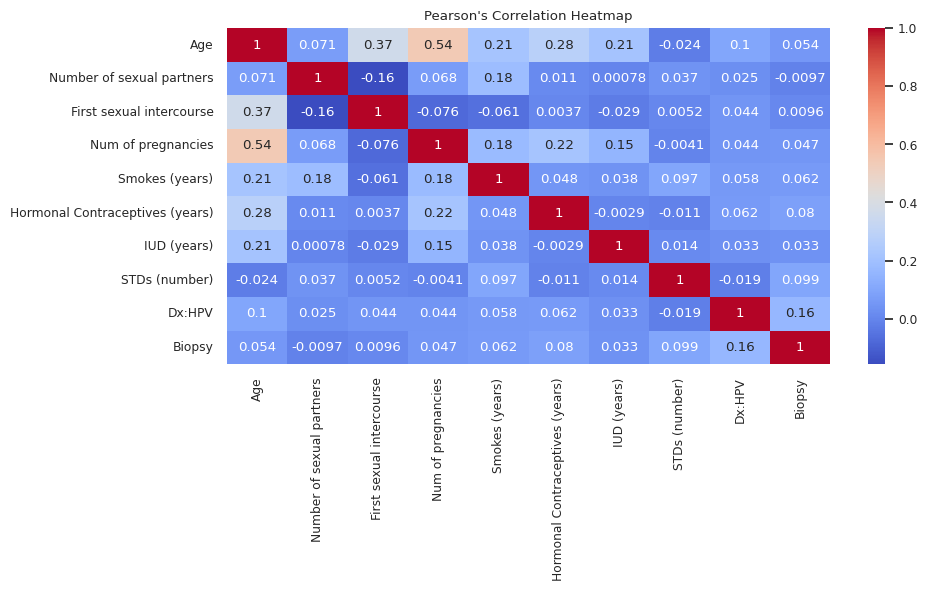

In [15]:
# @title **Pearson's correlation heatmap**

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)

sns.heatmap(
    df[corr_vars].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Pearson's Correlation Heatmap")
plt.tight_layout()
plt.show()

In [16]:
# @title **Spearman's Rank correlation table**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
df[corr_vars].corr(method='spearman')

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes (years),Hormonal Contraceptives (years),IUD (years),STDs (number),Dx:HPV,Biopsy
Age,1.000000,0.192222,0.428729,0.510468,0.054108,0.238907,0.286050,0.011536,0.101128,0.051265
Number of sexual partners,0.192222,1.000000,-0.133487,0.155204,0.240365,0.046584,0.072007,0.042012,0.031532,0.000232
First sexual intercourse,0.428729,-0.133487,1.000000,-0.043367,-0.139676,0.065745,-0.022166,0.000771,0.076325,0.039912
Num of pregnancies,0.510468,0.155204,-0.043367,1.000000,0.053697,0.261007,0.239904,0.033721,0.060282,0.069195
Smokes (years),0.054108,0.240365,-0.139676,0.053697,1.000000,0.040480,-0.050942,0.127323,0.013497,0.033168
Hormonal Contraceptives (years),0.238907,0.046584,0.065745,0.261007,0.040480,1.000000,0.045212,-0.013258,0.057032,0.021161
IUD (years),0.286050,0.072007,-0.022166,0.239904,-0.050942,0.045212,1.000000,0.052311,0.058984,0.053492
STDs (number),0.011536,0.042012,0.000771,0.033721,0.127323,-0.013258,0.052311,1.000000,-0.001621,0.109662
Dx:HPV,0.101128,0.031532,0.076325,0.060282,0.013497,0.057032,0.058984,-0.001621,1.000000,0.162142
Biopsy,0.051265,0.000232,0.039912,0.069195,0.033168,0.021161,0.053492,0.109662,0.162142,1.000000


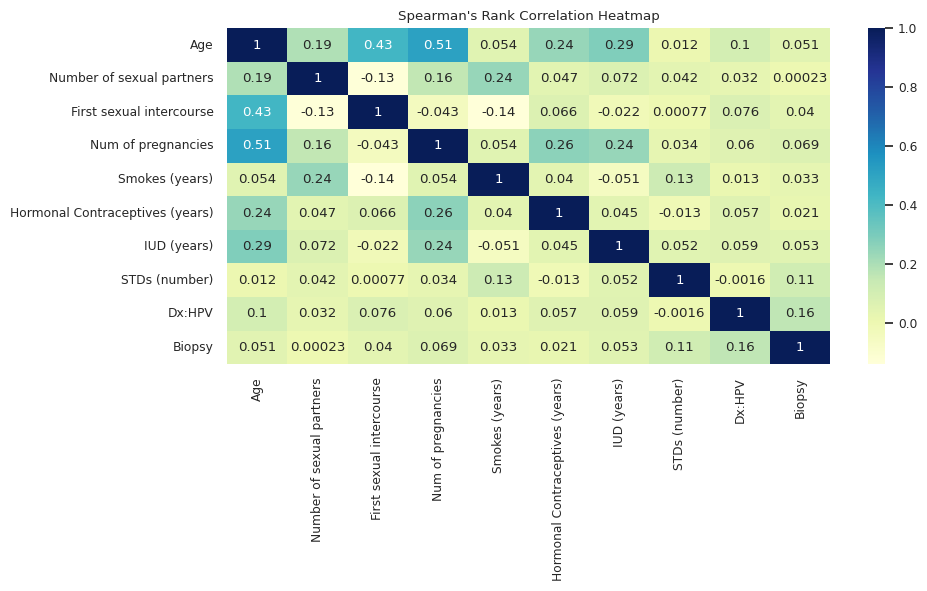

In [17]:
# @title **Spearman's Rank correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
plt.figure(figsize=(10,6))
sns.set(font_scale=0.8)
sns.heatmap(df[corr_vars].corr(method='spearman'), annot=True, cmap="YlGnBu")
plt.title("Spearman's Rank Correlation Heatmap")
plt.tight_layout()
plt.show()

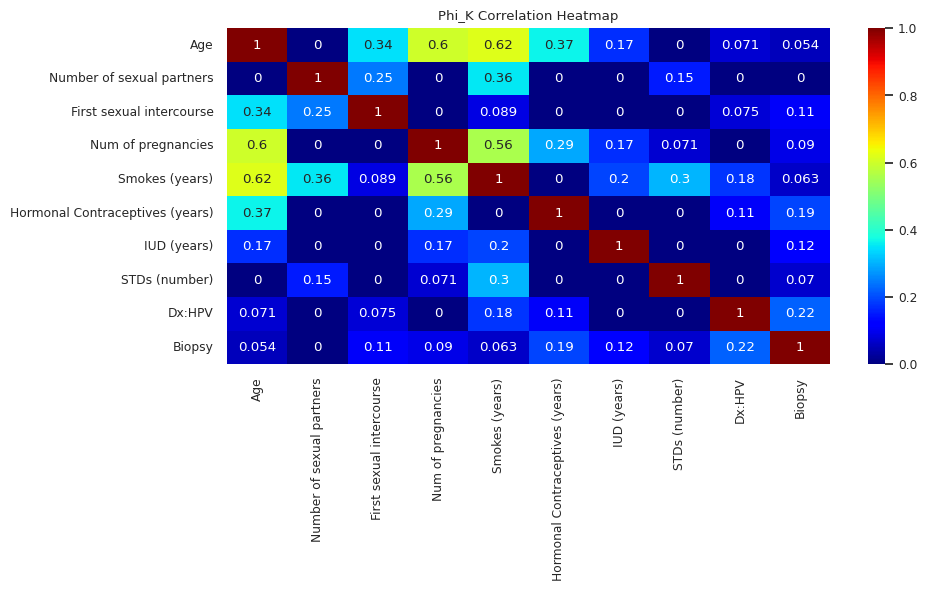

In [18]:
# @title **Phi-K correlation heatmap**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

import os
import sys
import subprocess

# Suppress pip install output
subprocess.run([sys.executable, "-m", "pip", "install", "phik"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import phik
from phik import resources, report
from phik.report import plot_correlation_matrix
from phik import phik_matrix

# Interval (numerical) columns among the selected variables; the rest are treated as categories
interval_cols = [col for col in corr_vars
                 if df[col].dtype in ["int64", "float64"] and df[col].nunique() > 2]

# Create correlation map using Phi-K
plt.figure(figsize=(10, 6))
sns.set(font_scale=0.8)

phik_corr = df[corr_vars].phik_matrix(interval_cols=interval_cols)
sns.heatmap(phik_corr, annot=True, cmap="jet")

plt.title("Phi_K Correlation Heatmap")
plt.tight_layout()
plt.show()


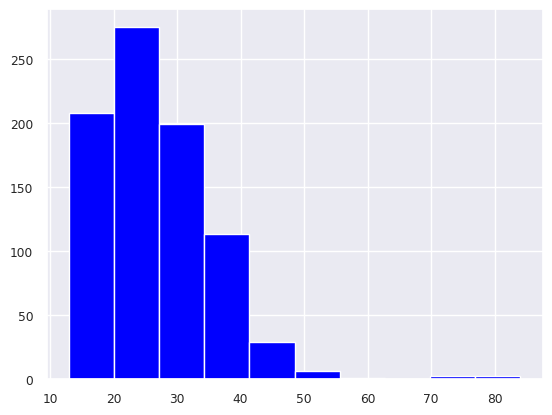

In [19]:
# @title **Example of a histogram**
plt.hist(df['Age'], color='blue'); # CHANGE VARIABLE HERE


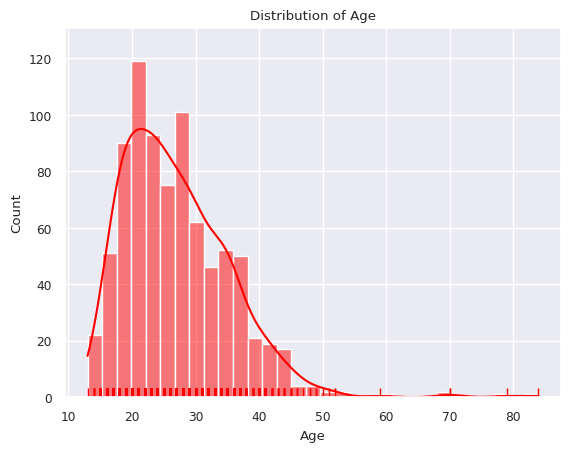

In [20]:
# @title **Example of a distribution plot**

import seaborn as sns
import matplotlib.pyplot as plt

variable = "Age"

sns.histplot(data=df, x=variable, color="red", kde=True)
sns.rugplot(data=df, x=variable, color="red")

plt.title(f"Distribution of {variable}")
plt.show()

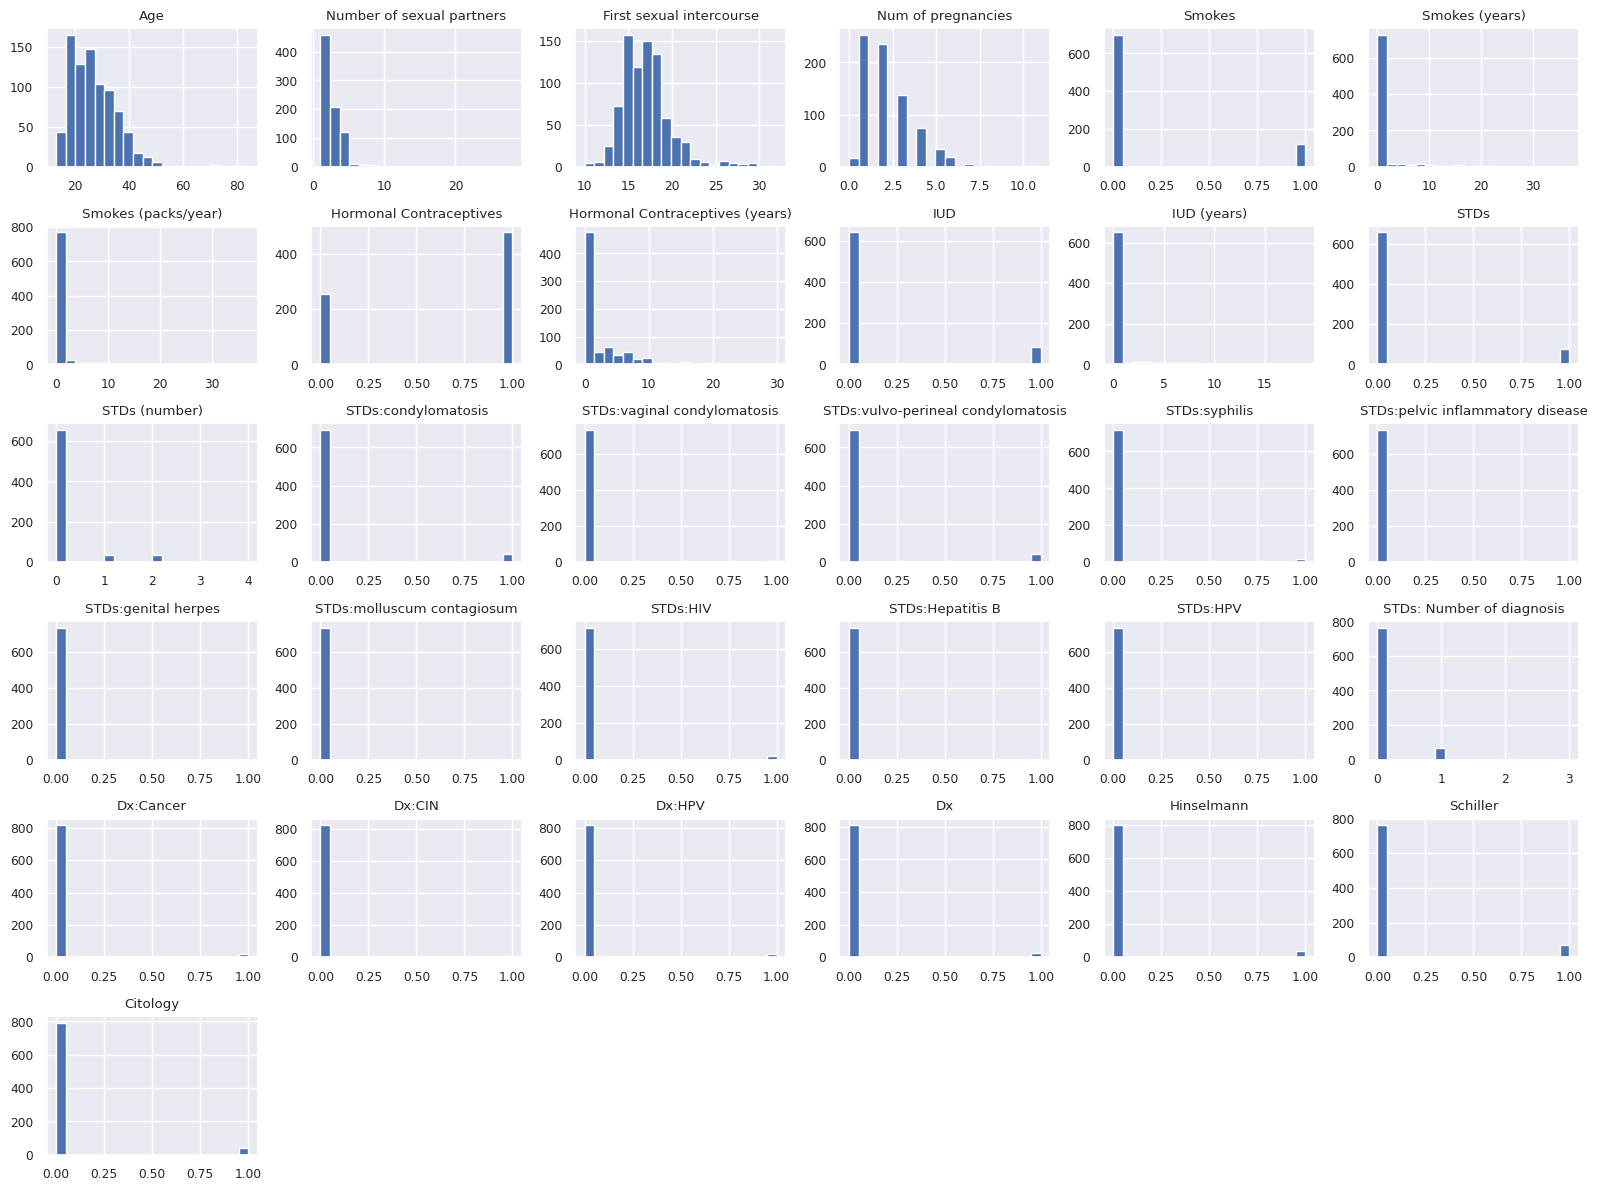

In [21]:
# @title **Generate histograms for all numerical variables**
df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

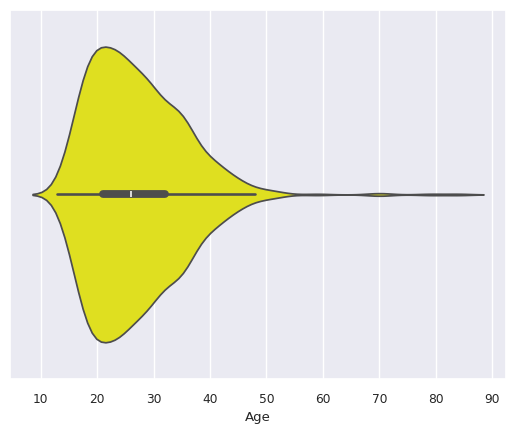

In [22]:
# @title **Example of a violin plot**
sns.violinplot(df['Age'], color='yellow', orient='h'); # CHANGE VARIABLE AND COLOR HERE

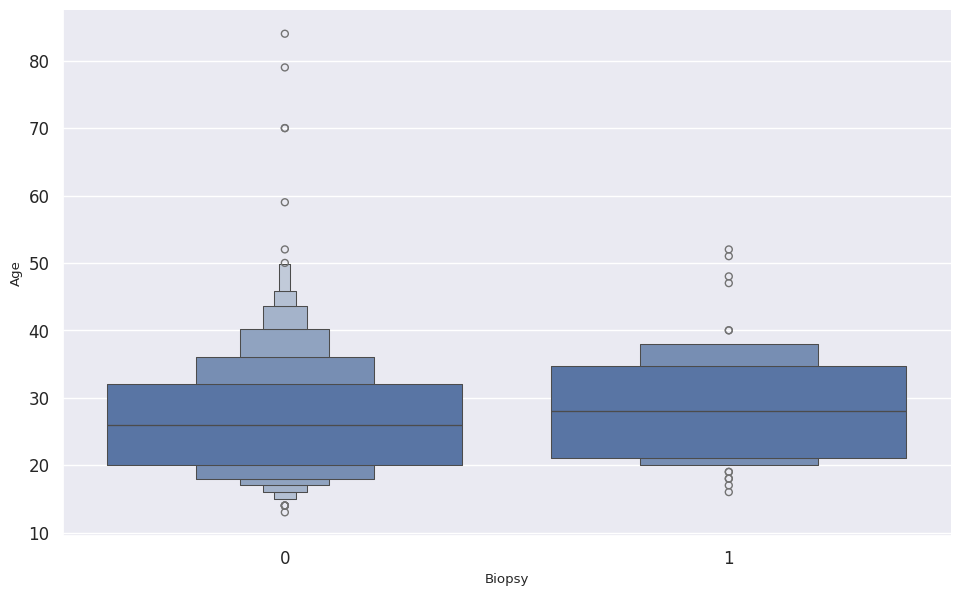

In [23]:
# @title **Example of categorical plot**
# Define the plot variables
x_var = "Biopsy"
y_var = "Age"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the plot
g = sns.catplot(x=x_var, y=y_var, data=df, kind='boxen', height=6, aspect=1.6, estimator=np.mean);

# Dynamically set axis labels
g.set_axis_labels(x_var, y_var)
g.set_titles("{col_name}")

# Optionally set font size
g.set(xlabel=x_var, ylabel=y_var)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [24]:
# @title **Define a function to create a boxplot and histogram combo**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
def histogram_boxplot(feature, figsize=(10,6), bins=None):
    """ Boxplot and histogram combined (horizontal boxplot version)
    feature: 1-d feature array
    figsize: size of fig (default (10,6))
    bins: number of bins (default None / auto)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from scipy.stats import norm

    sns.set(font_scale=1)
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (.25, .75)},
        figsize=figsize
    )

    # Horizontal boxplot
    sns.boxplot(x=feature, ax=ax_box2, showmeans=True, color='red')

    # Histogram
    if bins:
        sns.histplot(feature, kde=False, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(feature, kde=False, ax=ax_hist2)

    # Add central tendency lines to histogram
    ax_hist2.axvline(np.mean(feature), color='black', linestyle='--', label='Mean')
    ax_hist2.axvline(np.median(feature), color='green', linestyle='-', label='Median')
    ax_hist2.axvline(feature.mode()[0], color='red', linestyle='dashed', linewidth=1, label='Mode')

    ax_hist2.legend()
    plt.tight_layout()
    plt.show()

print("Function successfully created")

Function successfully created


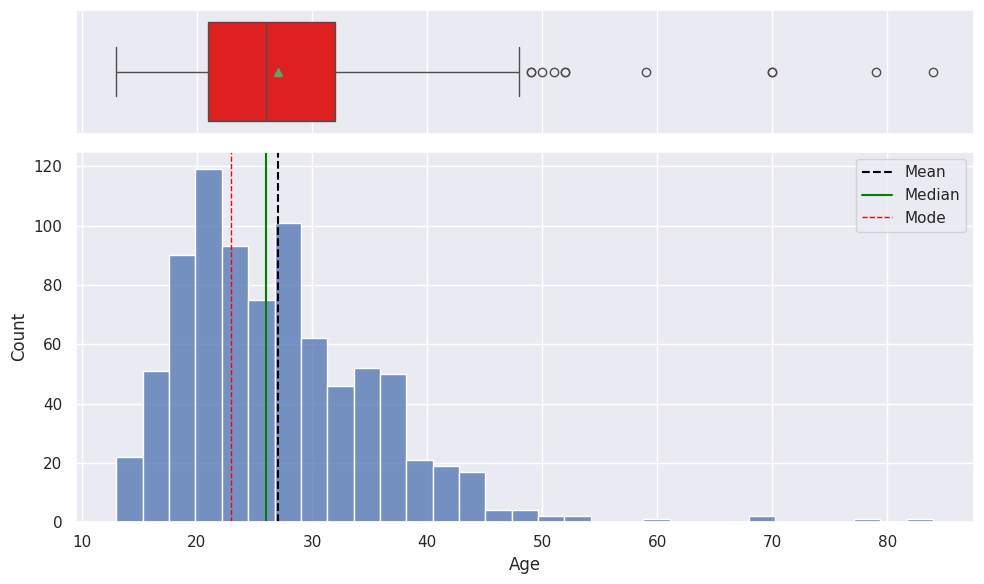

In [25]:
# @title **Example of a combination boxplot and histogram**

histogram_boxplot(df.Age) # CHANGE THE CONTINUOUS VARIABLE HERE

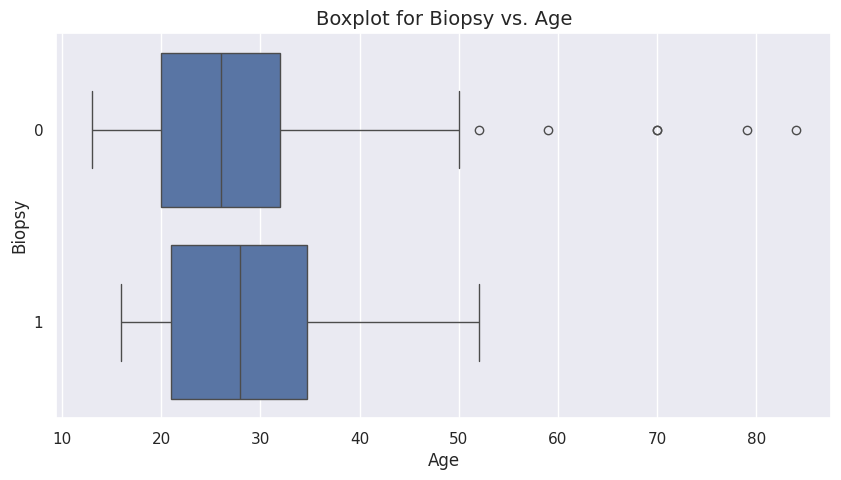

In [26]:
# @title **Example of boxplot with the primary outcome and a continuous variable**

# Define variables
x_var = "Age" # CHANGE VARIABLE HERE
y_var = "Biopsy"  # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=x_var, y=y_var, data=df)

# Dynamic labels and title
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'Boxplot for {y_var} vs. {x_var}', fontsize=14)

plt.show()

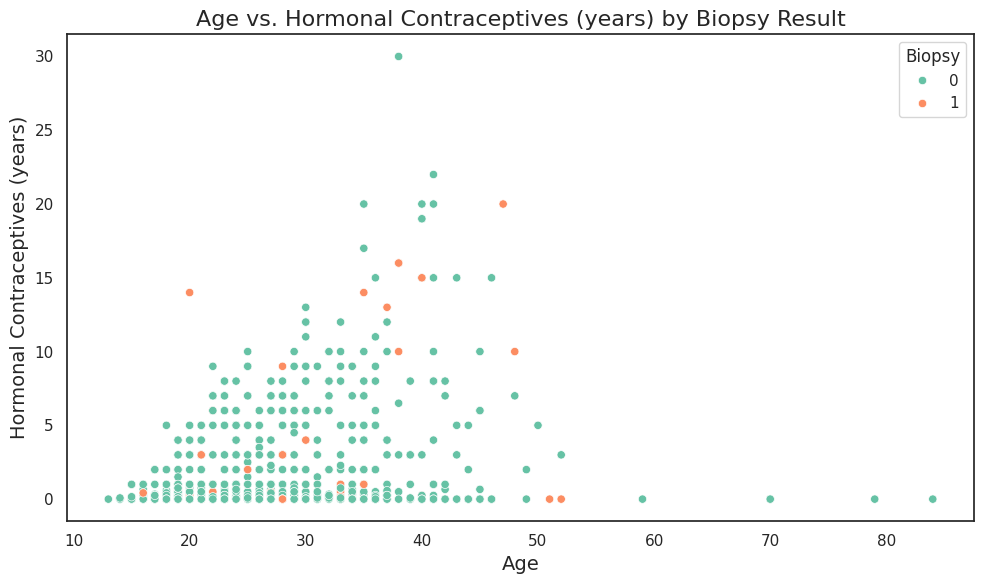

In [27]:
# @title **Example of a scatterplot**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Create the scatterplot
sns.set(style="white")  # Clean background without gridlines
plt.figure(figsize=(10, 6))

# Scatterplot
sns.scatterplot(x='Age', y='Hormonal Contraceptives (years)', hue='Biopsy', data=df, palette='Set2')

# Add title and axis labels
plt.title('Age vs. Hormonal Contraceptives (years) by Biopsy Result', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Hormonal Contraceptives (years)', fontsize=14)

# Remove gridlines
plt.grid(False)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

# Show the plot
plt.show()

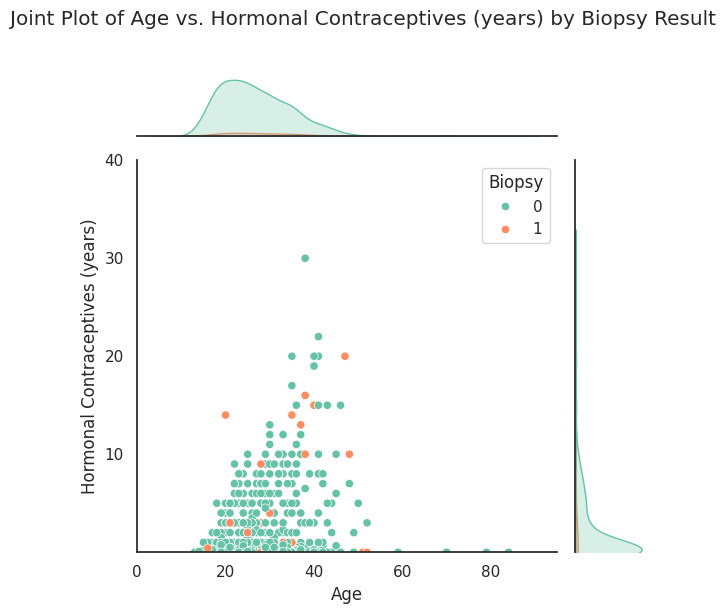

In [28]:
# @title **Example of a joint plot (3 variables)**
g = sns.jointplot(
    x='Age', # CHANGE VARIABLE HERE
    y='Hormonal Contraceptives (years)', # CHANGE VARIABLE HERE
    hue='Biopsy',
    data=df,
    palette='Set2',
    height=6,
)

# Set x-axis and y-axis limits
g.ax_joint.set_xlim(left=0)
g.ax_joint.set_ylim(bottom=0)

# Set y-axis ticks to increase by 10
y_min, y_max = g.ax_joint.get_ylim()
g.ax_joint.set_yticks(np.arange(10, y_max + 10, 10))

# Add title
plt.suptitle("Joint Plot of Age vs. Hormonal Contraceptives (years) by Biopsy Result", y=1.02)
plt.tight_layout()
plt.show()

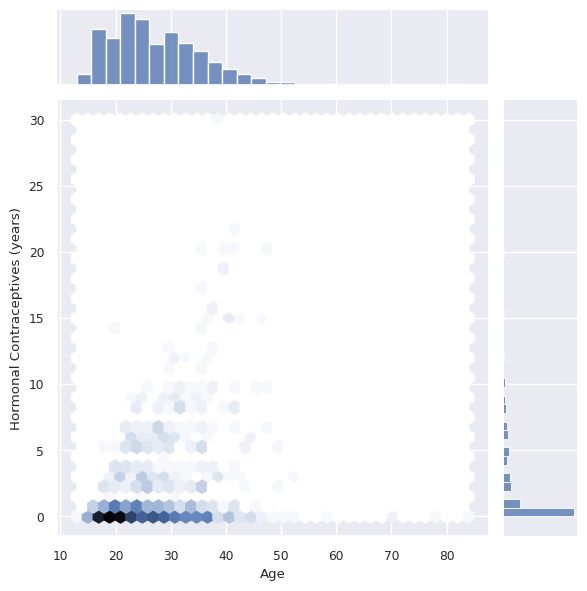

In [29]:
# @title **Example of a joint plot of a different kind (2 variables)**

sns.set(font_scale=0.8)

sns.jointplot(
    x='Age', # CHANGE VARIABLE HERE
    y='Hormonal Contraceptives (years)', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='hex',
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

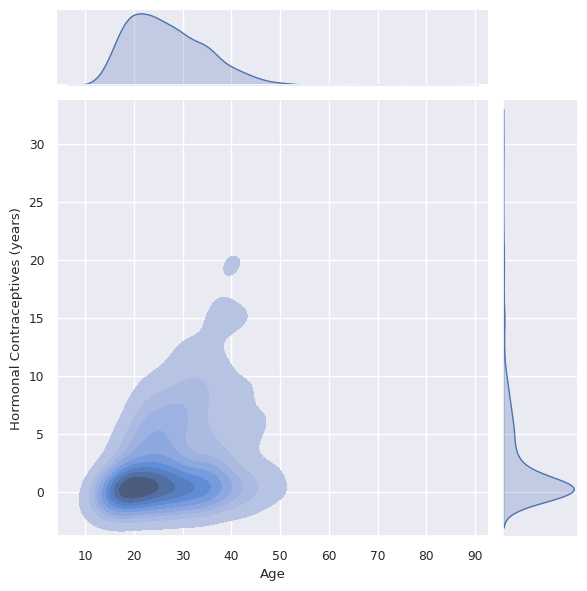

In [30]:
# @title **Another example of a joint plot of a different kind (2 variables)**
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=0.8)

sns.jointplot(
    x='Age', # CHANGE VARIABLE HERE
    y='Hormonal Contraceptives (years)', # CHANGE VARIABLE HERE #---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
    kind='kde',
    fill = True,
    data=df,
    palette='Set2',
    height=6  # Smaller and more compact
);

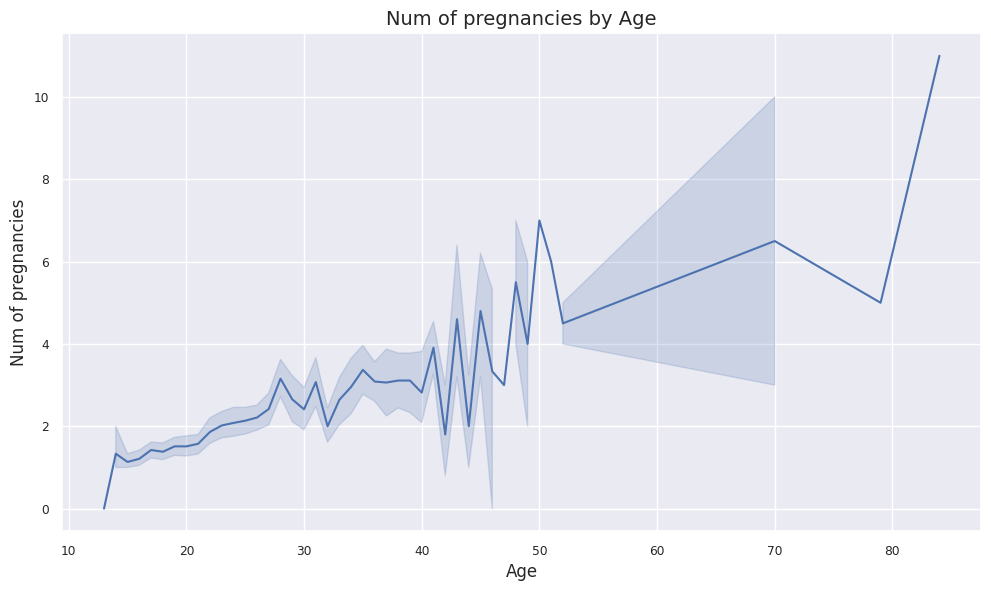

In [31]:
# @title **Example of a line plot**

# Define x and y columns
x_col = 'Age' # CHANGE VARIABLE HERE
y_col = 'Num of pregnancies' # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#

# Set up figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create lineplot
sns.lineplot(x=x_col, y=y_col, data=df, ax=ax)

# Set axis labels and title explicitly
ax.set_xlabel(x_col, fontsize=12)
ax.set_ylabel(y_col, fontsize=12)
ax.set_title(f'{y_col} by {x_col}', fontsize=14)

# Ensure labels are not cut off
plt.tight_layout()

# Show the plot
plt.show()

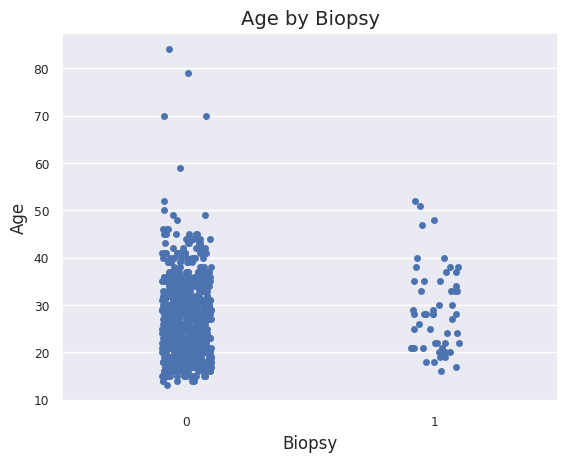

In [32]:
# @title **Example of a strip plot**

# Define axis variables
x_var = "Biopsy"  # CHANGE VARIABLE HERE
y_var = "Age"      # CHANGE VARIABLE HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
sns.stripplot(data=df, x=x_var, y=y_var, jitter=True)
plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

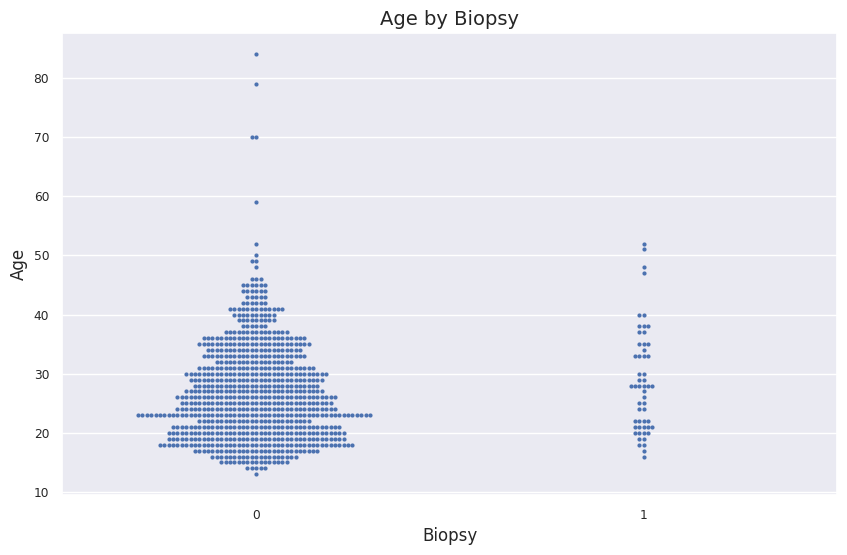

In [33]:
# @title **Example of a swarm plot**

x_var = "Biopsy"
y_var = "Age"

plt.figure(figsize=(10, 6))
sns.swarmplot(data=df, x=x_var, y=y_var, size=3)

plt.xlabel(x_var, fontsize=12)
plt.ylabel(y_var, fontsize=12)
plt.title(f'{y_var} by {x_var}', fontsize=14)
plt.show()

## **Inferential Statistics**

In [34]:
# @title **Import additional inferential statistics libraries**

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------------------------------#
import math
from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind

print("Libraries successfully imported.")

Libraries successfully imported.


In [35]:
# @title **Example of a one-sample t-test**

from scipy.stats import ttest_1samp

variable = "First sexual intercourse"       # CHANGE VARIABLE HERE
threshold = 18        # CHANGE REFERENCE VALUE HERE
alpha = 0.05          # CHANGE SIGNIFICANCE LEVEL HERE

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing observations.
values = df[variable].dropna()

if len(values) < 2 or values.std() == 0:
    raise ValueError(
        "The test requires at least two nonmissing values and nonzero variance."
    )

# Perform a two-sided one-sample t-test.
t_statistic, p_value = ttest_1samp(values, popmean=threshold)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"is {direction} than {threshold}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence that the population mean "
        f"{variable} differs from {threshold}."
    )

print(f"Null hypothesis: The population mean {variable} equals {threshold}.")
print(f"Alternative hypothesis: The population mean {variable} differs from {threshold}.")
print(f"\nNonmissing observations: {len(values)}")
print(f"Sample mean: {values.mean():.3f}")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean First sexual intercourse equals 18.
Alternative hypothesis: The population mean First sexual intercourse differs from 18.

Nonmissing observations: 826
Sample mean: 17.010
t-statistic: -10.170
p < 0.001
Decision: Reject the null hypothesis.
Interpretation: There is evidence that the population mean First sexual intercourse is lower than 18.


In [36]:
# @title **Independent samples t-test (specific to this dataset)**

from scipy.stats import ttest_ind

variable = "Age"
group_col = "Biopsy"
alpha = 0.05

label_map = {0: "Biopsy-negative patients", 1: "Biopsy-positive patients"}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing either the measurement or group.
test_data = df[[variable, group_col]].dropna()

if set(test_data[group_col].unique()) != {0, 1}:
    raise ValueError("The group variable must contain both groups, coded 0 and 1.")

# Set a consistent comparison order.
group1 = test_data.loc[test_data[group_col] == 0, variable]
group2 = test_data.loc[test_data[group_col] == 1, variable]

if len(group1) < 2 or len(group2) < 2:
    raise ValueError("Each group requires at least two nonmissing observations.")

if group1.var() == 0 and group2.var() == 0:
    raise ValueError("The test requires variation in at least one group.")

group1_name = label_map[0]
group2_name = label_map[1]

# Two-sided Welch's t-test.
t_statistic, p_value = ttest_ind(group1, group2, equal_var=False)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    direction = "higher" if t_statistic > 0 else "lower"
    interpretation = (
        f"There is evidence that the population mean {variable} "
        f"for {group1_name.lower()} is {direction} than "
        f"for {group2_name.lower()}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference in population "
        f"mean {variable} between the two groups."
    )

print(f"Null hypothesis: The population mean {variable} is equal between groups.")
print(f"Alternative hypothesis: The population mean {variable} differs between groups.")

print(f"\n{group1_name}: n = {len(group1)}, mean = {group1.mean():.3f}")
print(f"{group2_name}: n = {len(group2)}, mean = {group2.mean():.3f}")
print(f"Mean difference (group 0 − group 1): {group1.mean() - group2.mean():.3f}")

print(f"\nWelch's independent samples t-test:")
print(f"t-statistic: {t_statistic:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: The population mean Age is equal between groups.
Alternative hypothesis: The population mean Age differs between groups.

Biopsy-negative patients: n = 781, mean = 26.903
Biopsy-positive patients: n = 54, mean = 28.778
Mean difference (group 0 − group 1): -1.875

Welch's independent samples t-test:
t-statistic: -1.501
p = 0.139
Decision: Fail to reject the null hypothesis.
Interpretation: There is insufficient evidence of a difference in population mean Age between the two groups.


In [37]:
# @title **One-way ANOVA (specific to this dataset)**

import statsmodels.api as sm
from statsmodels.formula.api import ols

variable = "Hormonal Contraceptives (years)"
group_col = "Biopsy"
alpha = 0.05

label_map = {
    0: "Biopsy-negative patients",
    1: "Biopsy-positive patients"
}

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude observations missing the measurement or group.
test_data = df[[variable, group_col]].dropna().copy()

# Use standard column names for the model formula.
test_data.columns = ["measurement", "group"]
test_data["group"] = test_data["group"].astype("category")
test_data["group"] = test_data["group"].cat.remove_unused_categories()

group_summary = (
    test_data.groupby("group", observed=True)["measurement"]
    .agg(["count", "mean", "std"])
)

if len(group_summary) < 2:
    raise ValueError("ANOVA requires at least two groups.")

if (group_summary["count"] < 2).any():
    raise ValueError("Each group requires at least two nonmissing observations.")

if (group_summary["std"] == 0).all():
    raise ValueError("The test requires variation within at least one group.")

# Fit the model and calculate the ANOVA table.
anova_model = ols("measurement ~ C(group)", data=test_data).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

f_stat = anova_table.loc["C(group)", "F"]
p_value = anova_table.loc["C(group)", "PR(>F)"]

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

if p_value < alpha:
    decision = "Reject the null hypothesis."
    interpretation = (
        f"There is evidence that at least two groups differ "
        f"in population mean {variable}."
    )
else:
    decision = "Fail to reject the null hypothesis."
    interpretation = (
        f"There is insufficient evidence of a difference "
        f"in population mean {variable} across groups."
    )

# Apply readable group labels for display.
group_summary.index = [
    label_map.get(group, str(group))
    for group in group_summary.index
]

print(f"Null hypothesis: Population mean {variable} is equal across all groups.")
print(f"Alternative hypothesis: At least one population mean differs.")

print("\nGroup summaries:")
display(group_summary.round(3))

print("\nANOVA table:")
display(anova_table.round(3))

print(f"\nF-statistic: {f_stat:.3f}")
print(f"p {formatted_p}")
print(f"Decision: {decision}")
print(f"Interpretation: {interpretation}")

Null hypothesis: Population mean Hormonal Contraceptives (years) is equal across all groups.
Alternative hypothesis: At least one population mean differs.

Group summaries:


,count,mean,std
Biopsy-negative patients,678,2.217,3.623
Biopsy-positive patients,54,3.379,5.441



ANOVA table:


,sum_sq,df,F,PR(>F)
C(group),67.566,1.0,4.717,0.03
Residual,10455.763,730.0,NaN,NaN



F-statistic: 4.717
p = 0.030
Decision: Reject the null hypothesis.
Interpretation: There is evidence that at least two groups differ in population mean Hormonal Contraceptives (years).


In [38]:
# @title **Chi-square test of independence (specific to this dataset)**

import pandas as pd
from scipy.stats import chi2_contingency

group_col = "Biopsy"
variable = "STDs (number)"
threshold = 0
alpha = 0.05

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Exclude missing values before creating categories.
test_data = df[[group_col, variable]].dropna().copy()
test_data["Above threshold"] = test_data[variable] > threshold

crosstab = pd.crosstab(
    test_data[group_col],
    test_data["Above threshold"]
)

if crosstab.shape[0] < 2 or crosstab.shape[1] < 2:
    raise ValueError("The test requires at least two observed categories per variable.")

# Run Pearson's chi-square test without continuity correction.
chi2_stat, p_value, dof, expected = chi2_contingency(
    crosstab, correction=False
)

formatted_p = "< 0.001" if p_value < 0.001 else f"= {p_value:.3f}"

print("Observed counts (False = ≤ threshold; True = > threshold):")
display(crosstab)

print("\nExpected counts under independence:")
display(pd.DataFrame(
    expected,
    index=crosstab.index,
    columns=crosstab.columns
).round(3))

print(f"\nNull hypothesis: {group_col} and {variable} > {threshold} are independent.")
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p {formatted_p}")

if (expected < 5).any():
    print(
        "\nSmall expected counts detected. For this 2×2 table, "
        "consider Fisher's exact test before interpreting the chi-square result."
    )

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print(
        f"Interpretation: There is evidence of an association between "
        f"{group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )
else:
    print("Decision: Fail to reject the null hypothesis.")
    print(
        f"Interpretation: There is insufficient evidence of an association "
        f"between {group_col} and having {variable} > {threshold}, "
        "provided the test assumptions are met."
    )

Observed counts (False = ≤ threshold; True = > threshold):


Above threshold,False,True
Biopsy,,
0,616,67
1,40,12



Expected counts under independence:


Above threshold,False,True
Biopsy,,
0,609.589,73.411
1,46.411,5.589



Null hypothesis: Biopsy and STDs (number) > 0 are independent.
Chi-square statistic: 8.866
Degrees of freedom: 1
p = 0.003
Decision: Reject the null hypothesis.
Interpretation: There is evidence of an association between Biopsy and having STDs (number) > 0, provided the test assumptions are met.


In [39]:
# @title **Encode outcome labels as 0 and 1 (if needed)**

target_variable = "Biopsy"
label_map = {"Negative": 0, "Positive": 1}

outcome = df[target_variable]
observed_values = set(outcome.dropna().unique())

if observed_values.issubset({0, 1}):
    print("Outcome is already coded as 0/1.")

elif observed_values.issubset(set(label_map)):
    df[target_variable] = outcome.map(label_map)
    print("Outcome labels converted to 0/1.")

else:
    raise ValueError(
        f"Unexpected outcome values: {observed_values}. "
        "Update label_map to match your dataset."
    )

display(df[target_variable].head(10))

Outcome is already coded as 0/1.


,Biopsy
0,0
1,0
2,0
3,0
4,0
5,0
6,1
7,0
8,0
9,0


## **Supervised Machine Learning (Binary Classification)**

**Two examples:**
- Logistic Regression  
- Decision Tree  

**LOGISTIC REGRESSION:** Additional Info on Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

## **Logistic Regression**

In [40]:
# @title **Configure and split data for the automated ML pipeline**

from sklearn.model_selection import train_test_split

target_variable = "Biopsy"  # CHANGE FOR YOUR DATASET

# Other screening tests that closely track the biopsy result. Using them as predictors
# would be data leakage, so they are excluded from the predictors.
columns_to_exclude = ["Hinselmann", "Schiller", "Citology"]  # CHANGE FOR YOUR DATASET

# Exclude rows with missing outcomes; do not impute the outcome.
ml_data = df.dropna(subset=[target_variable]).copy()

excluded_found = [col for col in columns_to_exclude if col in ml_data.columns]
X = ml_data.drop(columns=[target_variable] + excluded_found)
y = ml_data[target_variable]

# This demonstration expects numeric predictors and an outcome coded 0/1.
if set(y.unique()) != {0, 1}:
    raise ValueError("The outcome must contain both classes, coded 0 and 1.")

if not all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns):
    raise ValueError("This pipeline requires numeric predictors.")

y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Excluded to avoid leakage: {excluded_found}")
print(f"Number of predictors: {X.shape[1]}")
print(f"Training observations: {len(X_train)} ({int(y_train.sum())} positive)")
print(f"Test observations: {len(X_test)} ({int(y_test.sum())} positive)")


Excluded to avoid leakage: ['Hinselmann', 'Schiller', 'Citology']
Number of predictors: 28
Training observations: 584 (38 positive)
Test observations: 251 (16 positive)


In [41]:
# @title **Define a function to display a confusion matrix**

from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_actual, y_predict):
    """Display counts and percentages of all evaluated observations."""

    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])

    if cm.sum() == 0:
        raise ValueError("No observations with labels 0 or 1 to display.")

    cell_names = np.array([
        ["True negative", "False positive"],
        ["False negative", "True positive"]
    ])

    annotations = np.array([
        f"{name}\n{count}\n{count / cm.sum():.2%}"
        for name, count in zip(cell_names.flatten(), cm.flatten())
    ]).reshape(2, 2)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=annotations,
        fmt="",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

print("Function successfully created.")

Function successfully created.


In [42]:
# @title **Build logistic regression with automated preprocessing**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Modification 3 (part a): class_weight="balanced" gives the rare positive class more
# weight, because only about 6% of patients have a positive biopsy.

# Learn imputation and scaling from training data only.
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

# Apply the fitted preprocessing and model to test data.
y_predict = logistic_pipeline.predict(X_test)
model_score = logistic_pipeline.score(X_test, y_test)

print(f"Test-set accuracy: {model_score:.2%}")
print(
    f"The model correctly classified {model_score:.2%} "
    "of observations in the test set."
)
print("Note: with a rare outcome, accuracy alone is misleading. See recall, precision, and PR AUC below.")


Test-set accuracy: 81.27%
The model correctly classified 81.27% of observations in the test set.
Note: with a rare outcome, accuracy alone is misleading. See recall, precision, and PR AUC below.


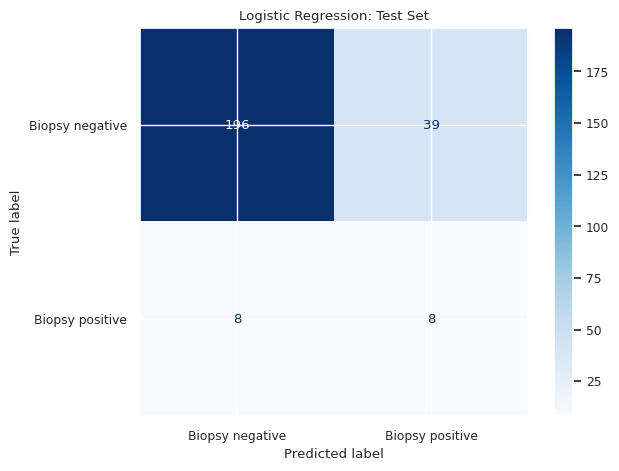

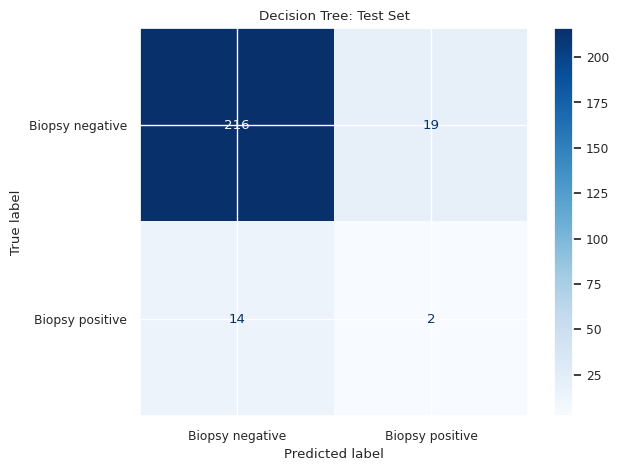

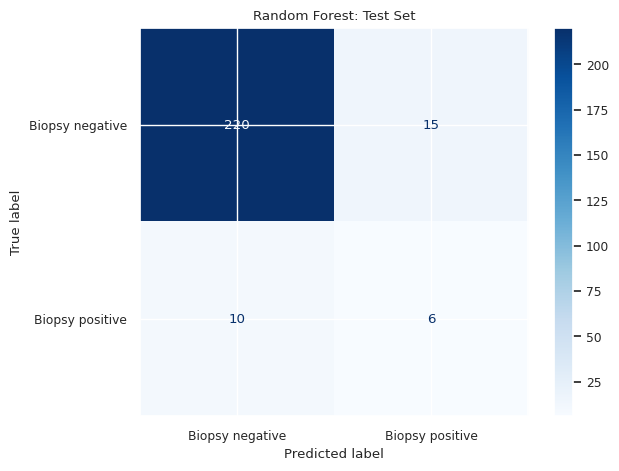

Test-set performance:


,Accuracy,Recall,Precision,F1,ROC AUC,PR AUC
Model,,,,,,
Logistic Regression,0.813,0.500,0.170,0.254,0.659,0.246
Decision Tree,0.869,0.125,0.095,0.108,0.522,0.068
Random Forest,0.900,0.375,0.286,0.324,0.722,0.228


Reference: a model with no skill has a PR AUC of about 0.064 (the share of positive biopsies).


In [43]:
# @title **Modification 4: Automatically preprocess, train, and compare ML models (added Random Forest and PR AUC)**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

# Define the models to run automatically.
# Modification 3 (part a): class_weight="balanced" for all models because of class imbalance.
# Modification 4: Random Forest added for comparison.
models = {
    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    )
}

trained_pipelines = {}
test_probabilities_by_model = {}
results = []

for model_name, classifier in models.items():

    # Preprocessing is fitted using training data only.
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    # Apply scaling when appropriate for the model.
    if isinstance(classifier, LogisticRegression):
        steps.append(("scaler", StandardScaler()))

    steps.append(("classifier", classifier))

    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    positive_index = list(pipeline.classes_).index(1)
    probabilities = pipeline.predict_proba(X_test)[:, positive_index]

    trained_pipelines[model_name] = pipeline
    test_probabilities_by_model[model_name] = probabilities

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probabilities),
        "PR AUC": average_precision_score(y_test, probabilities)
    })

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=[0, 1],
        display_labels=["Biopsy negative", "Biopsy positive"],
        cmap="Blues"
    )
    plt.title(f"{model_name}: Test Set")
    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).set_index("Model")

print("Test-set performance:")
display(results_df.round(3))
print(f"Reference: a model with no skill has a PR AUC of about {y_test.mean():.3f} (the share of positive biopsies).")


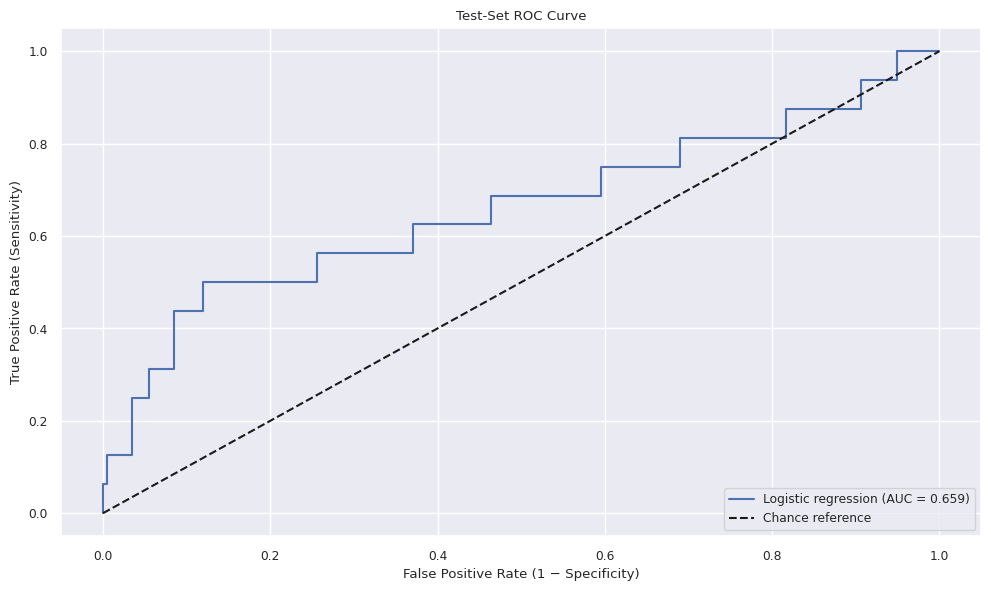

Test-set ROC AUC: 0.659


In [44]:
# @title **ROC curve and AUC for logistic regression**

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities for the positive class (1).
positive_index = list(logistic_pipeline.classes_).index(1)
y_probability = logistic_pipeline.predict_proba(X_test)[:, positive_index]

# Calculate test-set ROC AUC and curve.
logit_roc_auc = roc_auc_score(y_test, y_probability)
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {logit_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance reference")
plt.xlabel("False Positive Rate (1 − Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Test-Set ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Test-set ROC AUC: {logit_roc_auc:.3f}")

In [45]:
# @title **Modification 3 (part b): Select a cutoff using training-set cross-validation**

import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve

# Choose how the cutoff is selected:
#   "youden"     = maximum sensitivity + specificity - 1 (the original criterion)
#   "min_recall" = the highest cutoff that still reaches TARGET_RECALL (fewest false alarms)
THRESHOLD_CRITERION = "min_recall"   # CHANGE: "youden" or "min_recall"
TARGET_RECALL = 0.80                 # CHANGE: used only when THRESHOLD_CRITERION = "min_recall"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

# Use the logistic_pipeline defined in the training block.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

# Each observation is predicted by a pipeline trained on other folds.
# Imputation and scaling are learned separately within each fold.
cv_probabilities = cross_val_predict(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)

positive_index = list(logistic_pipeline.classes_).index(1)

fpr, tpr, thresholds = roc_curve(
    y_train,
    cv_probabilities[:, positive_index]
)

# Exclude the infinite threshold representing no positive predictions.
finite = np.isfinite(thresholds)

if THRESHOLD_CRITERION == "youden":
    j_scores = tpr[finite] - fpr[finite]
    optimal_idx = np.argmax(j_scores)
    criterion_text = "maximum cross-validation sensitivity + specificity - 1"

elif THRESHOLD_CRITERION == "min_recall":
    # Thresholds are in decreasing order, so the first one reaching the target recall is the highest.
    reaches_target = np.where(tpr[finite] >= TARGET_RECALL)[0]
    if len(reaches_target) == 0:
        raise ValueError("No cutoff reaches the target recall. Lower TARGET_RECALL.")
    optimal_idx = reaches_target[0]
    criterion_text = f"highest cutoff with cross-validation recall of at least {TARGET_RECALL:.0%}"

else:
    raise ValueError("THRESHOLD_CRITERION must be 'youden' or 'min_recall'.")

optimal_threshold = thresholds[finite][optimal_idx]

print(f"Selected threshold: {optimal_threshold:.3f}")
print(f"Criterion: {criterion_text}.")
print(f"Cross-validation recall at this cutoff: {tpr[finite][optimal_idx]:.3f}")
print(f"Cross-validation false positive rate at this cutoff: {fpr[finite][optimal_idx]:.3f}")
# For comparison: the original Youden criterion on the same cross-validation predictions.
youden_idx = np.argmax(tpr[finite] - fpr[finite])
print(f"\nFor comparison, the original Youden cutoff is {thresholds[finite][youden_idx]:.3f} "
      f"(cross-validation recall {tpr[finite][youden_idx]:.3f}, "
      f"false positive rate {fpr[finite][youden_idx]:.3f}).")
print("Apply the selected cutoff to the fitted pipeline's test-set probabilities.")

Selected threshold: 0.275
Criterion: highest cutoff with cross-validation recall of at least 80%.
Cross-validation recall at this cutoff: 0.816
Cross-validation false positive rate at this cutoff: 0.859

For comparison, the original Youden cutoff is 0.520 (cross-validation recall 0.447, false positive rate 0.187).
Apply the selected cutoff to the fitted pipeline's test-set probabilities.


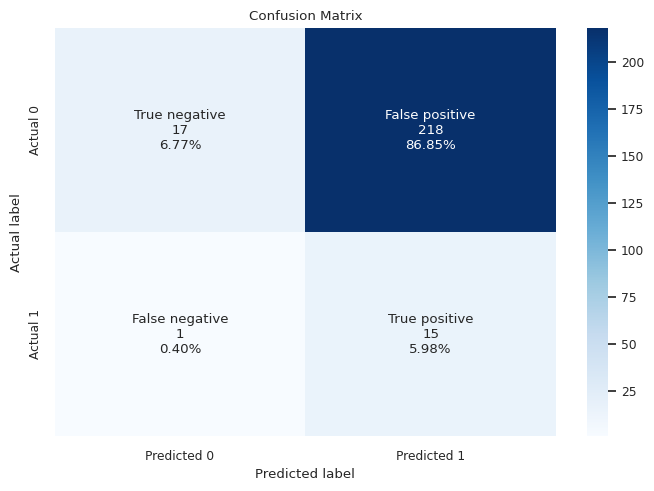

In [46]:
# @title **Make confusion matrix using the selected cutoff**

positive_index = list(logistic_pipeline.classes_).index(1)

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

make_confusion_matrix(y_test, y_pred_ts)

In [47]:
# @title **Compare training and test F1 at the selected cutoff**

from sklearn.metrics import f1_score

positive_index = list(logistic_pipeline.classes_).index(1)

train_probabilities = logistic_pipeline.predict_proba(
    X_train
)[:, positive_index]

test_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, positive_index]

y_pred_tr = (train_probabilities >= optimal_threshold).astype(int)
y_pred_ts = (test_probabilities >= optimal_threshold).astype(int)

print(f"Selected cutoff: {optimal_threshold:.3f}")
print(f"Training F1: {f1_score(y_train, y_pred_tr, zero_division=0):.3f}")
print(f"Test F1: {f1_score(y_test, y_pred_ts, zero_division=0):.3f}")

Selected cutoff: 0.275
Training F1: 0.131
Test F1: 0.120


## **Decision Tree**

**DECISION TREE: https://scikit-learn.org/stable/modules/tree.html#**

In [48]:
# @title **Import libraries for decision tree training and evaluation**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Decision tree libraries imported successfully.")

Decision tree libraries imported successfully.


In [49]:
# @title **Build and tune decision tree using cross-validation F1**

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Choose the metric used for tuning.
scoring_metric = "f1"  # Alternatives: "recall", "precision", "accuracy"

#---------------------DO NOT CHANGE ANY CODE BELOW THIS LINE---------------------#

dtree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Pipeline parameters require the step name prefix.
parameters = {
    "classifier__max_depth": [2, 4, 6, 8],
    "classifier__min_samples_leaf": [5, 10, 15],
    "classifier__max_leaf_nodes": [5, 10, 15],
    "classifier__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

if y_train.value_counts().min() < 5:
    raise ValueError("Each training class needs at least 5 observations.")

grid_obj = GridSearchCV(
    estimator=dtree_pipeline,
    param_grid=parameters,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_obj.fit(X_train, y_train)

# Already refitted on the full training set; no additional fit is needed.
dtree = grid_obj.best_estimator_

print("Decision tree pipeline built and tuned.")
print(f"Best mean cross-validation {scoring_metric}: {grid_obj.best_score_:.3f}")
print("Selected parameters:")
print(grid_obj.best_params_)

Decision tree pipeline built and tuned.
Best mean cross-validation f1: 0.221
Selected parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 4, 'classifier__max_leaf_nodes': 10, 'classifier__min_samples_leaf': 10}


In [50]:
# @title **Function to calculate accuracy, recall, precision, and F1**

from sklearn import metrics

def get_metrics_score(model, flag=True):
    """Evaluate a fitted classifier on the existing training and test sets."""

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_acc = metrics.accuracy_score(y_train, pred_train)
    test_acc = metrics.accuracy_score(y_test, pred_test)

    train_recall = metrics.recall_score(
        y_train, pred_train, zero_division=0
    )
    test_recall = metrics.recall_score(
        y_test, pred_test, zero_division=0
    )

    train_precision = metrics.precision_score(
        y_train, pred_train, zero_division=0
    )
    test_precision = metrics.precision_score(
        y_test, pred_test, zero_division=0
    )

    train_f1 = metrics.f1_score(y_train, pred_train, zero_division=0)
    test_f1 = metrics.f1_score(y_test, pred_test, zero_division=0)

    score_list = [
        train_acc, test_acc,
        train_recall, test_recall,
        train_precision, test_precision,
        train_f1, test_f1
    ]

    if flag:
        print(f"{'Metric':<12} {'Training':>10} {'Test':>10}")
        for name, train_value, test_value in [
            ("Accuracy", train_acc, test_acc),
            ("Recall", train_recall, test_recall),
            ("Precision", train_precision, test_precision),
            ("F1", train_f1, test_f1)
        ]:
            print(f"{name:<12} {train_value:>10.3f} {test_value:>10.3f}")

    return score_list

print("Metric evaluation function successfully defined.")

Metric evaluation function successfully defined.


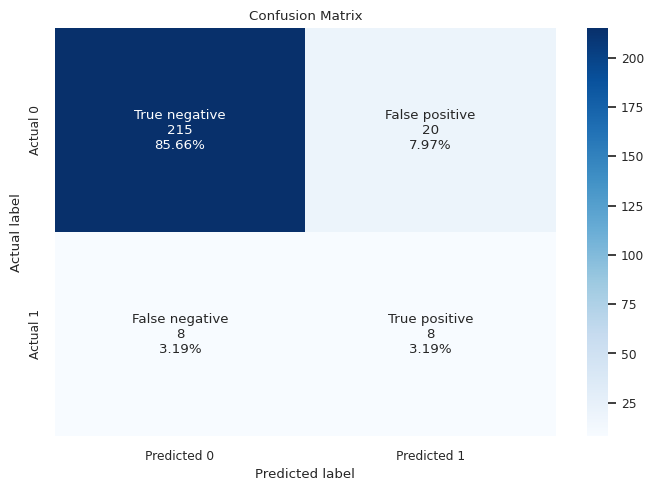

In [51]:
# @title **Display confusion matrix for the tuned decision tree**

y_pred_tree = dtree.predict(X_test)

make_confusion_matrix(y_test, y_pred_tree)

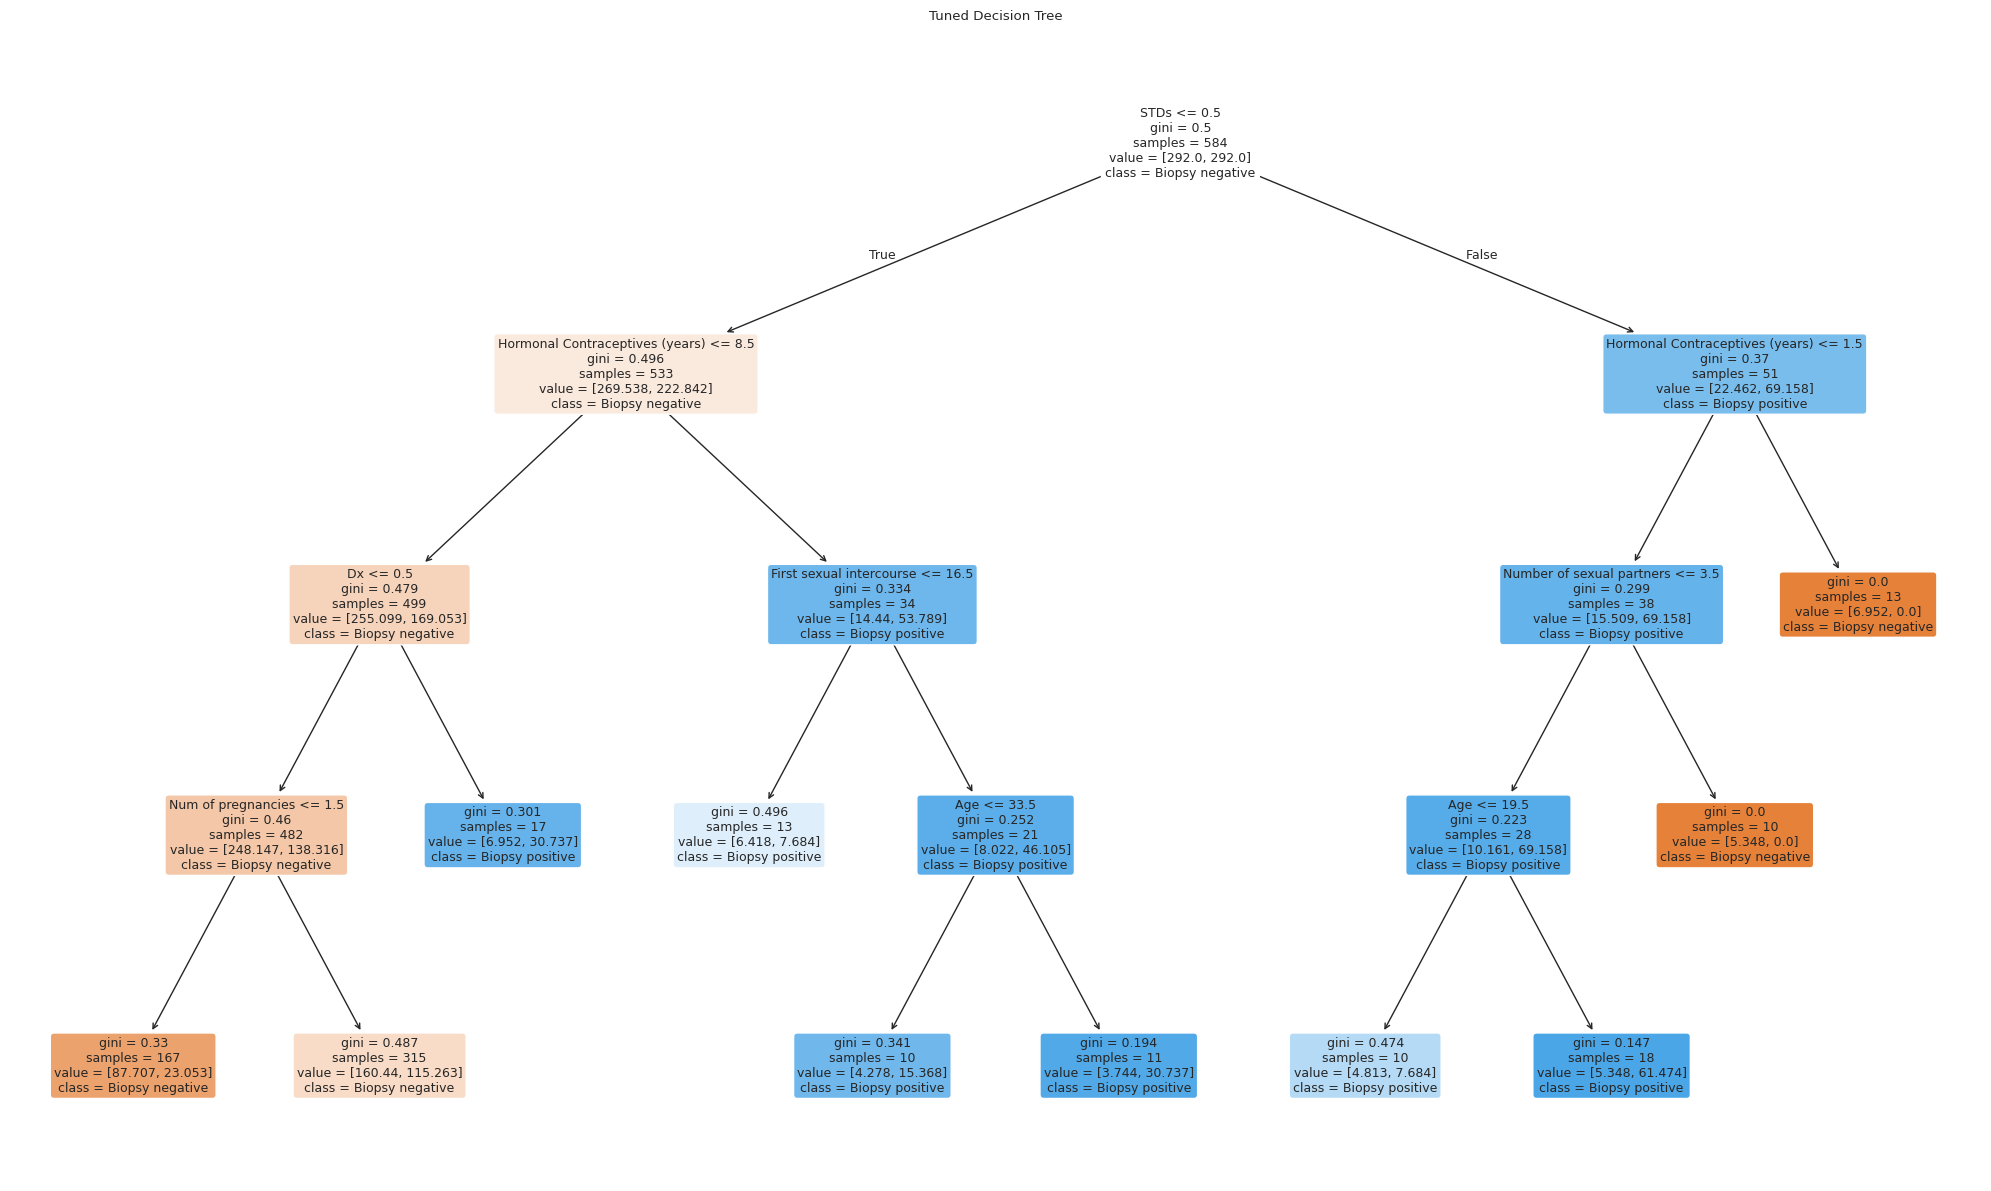

In [52]:
# @title **Show the tuned decision tree**

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

plt.figure(figsize=(20, 12))

plot_tree(
    tree_classifier,
    feature_names=list(feature_names),
    class_names=["Biopsy negative", "Biopsy positive"],
    filled=True,
    rounded=True,
    fontsize=9,
    node_ids=False
)

plt.title("Tuned Decision Tree")
plt.tight_layout()
plt.show()

In [53]:
# @title **List feature importance from the tuned decision tree**

import pandas as pd

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.reset_index(drop=True).round(3))

,Feature,Importance
0,Hormonal Contraceptives (years),0.358
1,Dx,0.195
2,STDs,0.191
3,Number of sexual partners,0.103
4,Num of pregnancies,0.094
5,Age,0.031
6,First sexual intercourse,0.029
7,Smokes,0.000
8,Hormonal Contraceptives,0.000
9,Smokes (packs/year),0.000


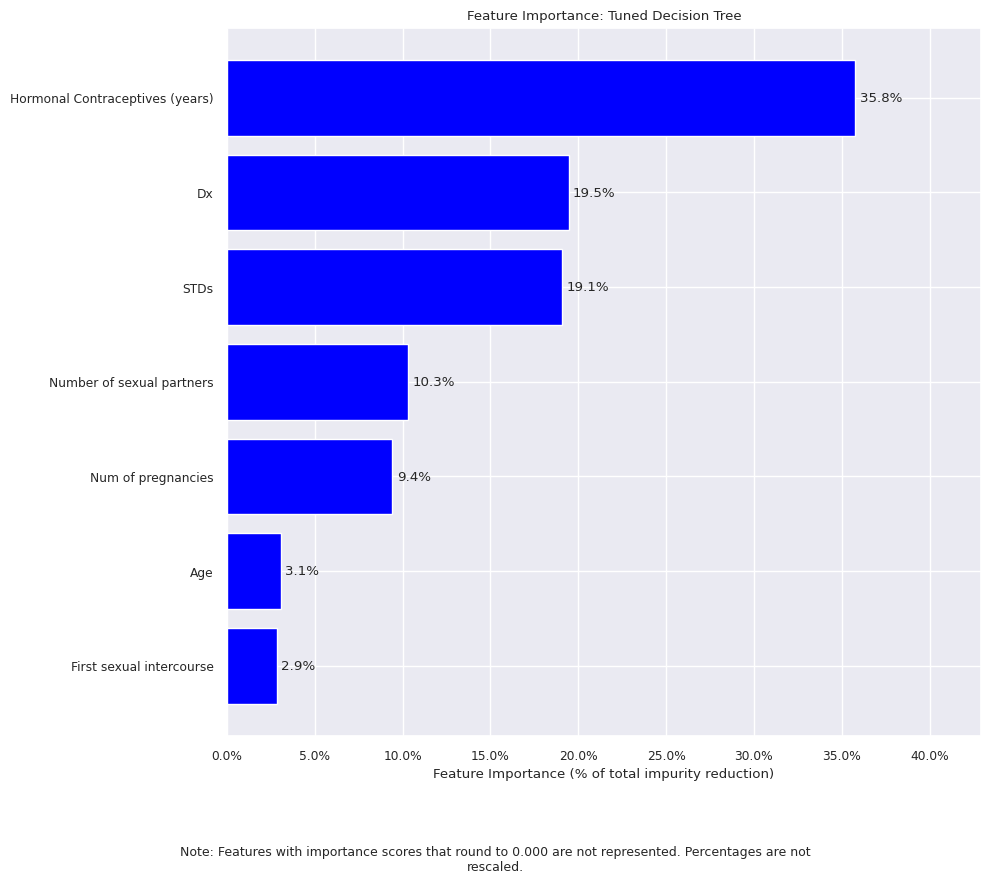

Highest-ranked features in this fitted tree:
- Hormonal Contraceptives (years): 35.8%
- Dx: 19.5%
- STDs: 19.1%

Excluded features (importance rounds to 0.000): Smokes, Smokes (years), Smokes (packs/year), Hormonal Contraceptives, IUD, IUD (years), STDs (number), STDs:condylomatosis, STDs:vaginal condylomatosis, STDs:vulvo-perineal condylomatosis, STDs:syphilis, STDs:pelvic inflammatory disease, STDs:genital herpes, STDs:molluscum contagiosum, STDs:HIV, STDs:Hepatitis B, STDs:HPV, STDs: Number of diagnosis, Dx:Cancer, Dx:CIN, Dx:HPV

These percentages describe each feature's share of total impurity reduction, not its effect on the risk of a positive biopsy.


In [54]:
# @title **Visualize feature importance from the tuned decision tree**

import numpy as np
import matplotlib.pyplot as plt
import textwrap
from matplotlib.ticker import PercentFormatter

tree_classifier = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["imputer"].get_feature_names_out()
importances = tree_classifier.feature_importances_

# Exclude scores that round to 0.000 at three decimal places.
included = np.round(importances, 3) > 0
excluded_features = feature_names[~included].tolist()

excluded_note = (
    "Excluded features (importance rounds to 0.000): "
    + ", ".join(excluded_features)
    if excluded_features
    else "No features were excluded."
)

if included.any():
    shown_names = feature_names[included]
    shown_importances = importances[included]
    indices = np.argsort(shown_importances)

    note = textwrap.fill(
        "Note: Features with importance scores that round to 0.000 "
        "are not represented. Percentages are not rescaled.",
        width=100
    )
    note_lines = len(note.splitlines())
    bottom_margin = 0.6 + 0.18 * note_lines
    figure_height = 8 + bottom_margin

    fig, ax = plt.subplots(figsize=(10, figure_height))

    bars = ax.barh(
        range(len(indices)),
        shown_importances[indices],
        color="blue"
    )

    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels(shown_names[indices])
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

    ax.bar_label(
        bars,
        labels=[f"{value:.1%}" for value in shown_importances[indices]],
        padding=3
    )

    ax.set_xlim(0, shown_importances.max() * 1.2)
    ax.set_xlabel("Feature Importance (% of total impurity reduction)")
    ax.set_title("Feature Importance: Tuned Decision Tree")

    fig.text(
        0.5, 0.02,
        note,
        ha="center",
        va="bottom",
        fontsize=9
    )

    plt.tight_layout(
        rect=[0, bottom_margin / figure_height, 1, 1]
    )
    plt.show()

    print("Highest-ranked features in this fitted tree:")
    for index in indices[::-1][:3]:
        print(f"- {shown_names[index]}: {shown_importances[index]:.1%}")

else:
    print("All feature importance scores round to 0.000; no graph displayed.")

print(f"\n{excluded_note}")
print(
    "\nThese percentages describe each feature's share of total "
    "impurity reduction, not its effect on the risk of a positive biopsy."
)

## **Interpretation of the Modified Outputs**

The modified notebook runs from start to finish without errors. All numbers below come from the outputs above, and the random seeds are fixed, so they are the same on every run.

### Modification 1: Data loading
The notebook loaded risk_factors_cervical_cancer.csv from GitHub with no manual upload. It reads 858 rows and 36 columns, and the ? placeholders became true missing values.

### Modification 2: Automatic cleaning
- 2 patients had a first-intercourse age later than their current age, so those values became missing.
- 4 columns were dropped: two were about 92% empty and two had the same value for everyone.
- 23 duplicate rows were removed.
- The data went from 858 x 36 to 835 rows x 32 columns, leaving 28 predictors after removing the target and the three other screening tests.

### Statistical tests
- **Age at first intercourse:** the average was 17.0 years, significantly lower than 18 (p < 0.001).
- **Age by biopsy result:** positive patients were slightly older (28.8 vs. 26.9 years), but the difference was not significant (p = 0.139).
- **Years of hormonal contraceptive use:** positive patients averaged more (3.4 vs. 2.2 years, p = 0.030).
- **Any STD vs. biopsy result:** about 23% of positive patients had an STD, compared with about 10% of negative patients (p = 0.003).

### Model performance
The test set had 251 patients, and only 16 had a positive biopsy.
- **Logistic regression:** recall 0.50, F1 0.254, PR AUC 0.246.
- **Decision tree:** recall 0.125, F1 0.108, PR AUC 0.068.
- **Random forest:** recall 0.375, F1 0.324, PR AUC 0.228, and the highest ROC AUC (0.722).

Accuracy is misleading here. Always predicting "negative" would be 93.6% accurate, which is higher than every model, but it would find no cases. That is why the focus is on recall, F1, and PR AUC. Based on the models, risk-factor history alone does not predict a positive biopsy very well.

### Modification 3: Class weights and cutoff
- The original cutoff (0.520) found only 44.7% of positives in cross-validation.
- The new target-recall cutoff (0.275) found 81.6%, but it also flagged 85.9% of negative patients by mistake.
- On the test set, it found 15 of 16 positive patients but flagged 233 of 251 patients overall.

The cutoff only trades missed cases for false alarms. It cannot add information the model does not have. Here, catching most cases means flagging almost everyone, which would not help a clinic decide who to follow up first.

### Tuned decision tree
Tuning helped. The tuned tree found 8 of 16 positive patients, compared with 2 for the untuned tree, with 20 false positives. The most important features were years of hormonal contraceptive use, Dx, and STDs. These show which variables the tree used most, not how they change risk.

### Why the modifications fit this dataset
1. **Data loading:** the raw file uses ? for missing answers, and the notebook runs with no upload needed.
2. **Cleaning:** empty, constant, and duplicate data add noise, and duplicates in both the training and test sets would inflate performance.
3. **Class weights and cutoff:** only about 6% of patients are biopsy positive, so an unweighted model and a 0.5 cutoff favor predicting "negative."
4. **Random forest and PR AUC:** PR AUC is more useful than ROC AUC when positives are rare, and a second model checks whether a different method finds more signal.

### Limitations
The test set has only 16 positive patients, so the performance numbers are uncertain and would change with a different split. Also, the data come from a single hospital.
